<a href="https://colab.research.google.com/github/Taniya-roy20/ML-PROJECT/blob/main/Polynomial_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)

Saving FAOSTAT_data_en_8-19-2026.csv to FAOSTAT_data_en_8-19-2026.csv
Uploaded file: FAOSTAT_data_en_8-19-2026.csv


In [3]:
import pandas as pd

# Dataset load karke unique Areas count karte hain
df = pd.read_csv('FAOSTAT_data_en_8-19-2026.csv')
print("Unique Areas in dataset:\n", df['Area'].unique())
print("\nTotal Unique Areas:", df['Area'].nunique())

Unique Areas in dataset:
 ['India']

Total Unique Areas: 1


----- Polynomial Regression -----
Polynomial Degree : 2

Model Equation:
        2
0.4621 x - 1771 x + 1.7e+06

----- Model Evaluation -----
MSE      : 630972.4573
RMSE     : 794.3377
MAE      : 593.8240
R² Score : 0.7317

----- Predicted Yield -----
2027 -> 8820.81 kg/ha
2028 -> 8923.77 kg/ha
2029 -> 9027.64 kg/ha
2030 -> 9132.44 kg/ha

Graph saved to polynomial_regression_plot.png


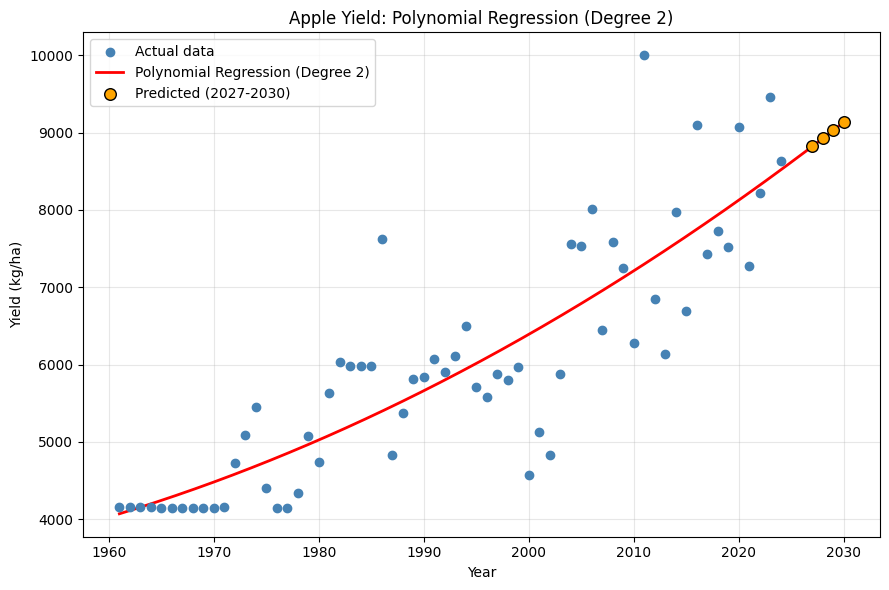

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------------
# Load Dataset
# --------------------------------

def load_data(path):
    df = pd.read_csv(path)

    year_col = df.columns[9]
    yield_col = df.columns[11]

    data = df[[year_col, yield_col]].copy()
    data.columns = ["year", "yield"]

    data["year"] = pd.to_numeric(data["year"], errors="coerce")
    data["yield"] = pd.to_numeric(data["yield"], errors="coerce")

    data = data.dropna()

    data["year"] = data["year"].astype(int)

    return data


# --------------------------------
# Polynomial Regression
# --------------------------------

def train_polynomial_regression(years, yields, degree):
    coefficients = np.polyfit(years, yields, degree)
    model = np.poly1d(coefficients)

    return model


def predict(model, years):
    return model(years)


# --------------------------------
# Evaluation Metrics
# --------------------------------

def calculate_mse(actual, predicted):
    return np.mean((actual - predicted) ** 2)


def calculate_rmse(actual, predicted):
    mse = calculate_mse(actual, predicted)
    return np.sqrt(mse)


def calculate_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))


def calculate_r2(actual, predicted):
    ss_res = np.sum((actual - predicted) ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)

    return 1 - (ss_res / ss_tot)


# --------------------------------
# Main Program
# --------------------------------

CSV_PATH = "FAOSTAT_data_en_8-19-2026.csv"

# Change this to 3 or 4 if required
DEGREE = 2

data = load_data(CSV_PATH)


if data.empty:

    print("No data found!")

else:

    years = data["year"].to_numpy()
    yields = data["yield"].to_numpy()

    # Train Polynomial Regression
    model = train_polynomial_regression(
        years,
        yields,
        DEGREE
    )

    # Predictions for historical data
    predicted_yields = predict(
        model,
        years
    )

    # --------------------------------
    # Evaluation Metrics
    # --------------------------------

    mse = calculate_mse(
        yields,
        predicted_yields
    )

    rmse = calculate_rmse(
        yields,
        predicted_yields
    )

    mae = calculate_mae(
        yields,
        predicted_yields
    )

    r2 = calculate_r2(
        yields,
        predicted_yields
    )

    # --------------------------------
    # Display Results
    # --------------------------------

    print("----- Polynomial Regression -----")

    print(f"Polynomial Degree : {DEGREE}")

    print("\nModel Equation:")
    print(model)

    print("\n----- Model Evaluation -----")

    print(f"MSE      : {mse:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"R² Score : {r2:.4f}")

    # --------------------------------
    # Future Predictions
    # --------------------------------

    predict_years = np.arange(2027, 2031)

    predict_yields = predict(
        model,
        predict_years
    )

    print("\n----- Predicted Yield -----")

    for year, prediction in zip(
        predict_years,
        predict_yields
    ):
        print(
            f"{year} -> {prediction:.2f} kg/ha"
        )

    # --------------------------------
    # Plot
    # --------------------------------

    plt.figure(figsize=(9, 6))

    # Actual data
    plt.scatter(
        years,
        yields,
        color="steelblue",
        label="Actual data",
        zorder=3
    )

    # Smooth polynomial curve
    line_years = np.linspace(
        years.min(),
        predict_years.max(),
        500
    )

    line_yields = predict(
        model,
        line_years
    )

    plt.plot(
        line_years,
        line_yields,
        color="red",
        linewidth=2,
        label=f"Polynomial Regression (Degree {DEGREE})"
    )

    # Future predictions
    plt.scatter(
        predict_years,
        predict_yields,
        color="orange",
        edgecolor="black",
        s=70,
        label="Predicted (2027-2030)",
        zorder=4
    )

    plt.title(
        f"Apple Yield: Polynomial Regression (Degree {DEGREE})"
    )

    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "polynomial_regression_plot.png",
        dpi=150
    )

    print(
        "\nGraph saved to polynomial_regression_plot.png"
    )

    plt.show()